# 🏢⚡ Building Energy Consumption Prediction
### Open-Ended Lab (OEL) — Artificial Intelligence Lab

**Paradigm:** Supervised Learning — Regression
**Course:** Artificial Intelligence Lab
**Group Size:** Up to 3 Students

---

**Problem Statement:**
Energy consumption in commercial, residential, and industrial buildings is
driven by measurable physical and behavioural factors — floor area, number
of occupants, appliance load, ambient temperature, and the day of the week.
Being able to *predict* a building's energy consumption from these factors
lets facility managers detect abnormal usage, plan capacity, and design
energy-efficiency interventions before a bill ever arrives.

**Goal of this notebook:** build, tune, and rigorously evaluate machine
learning models that predict a building's **Energy Consumption (kWh)**
from its physical and operational characteristics.

This notebook is organised to match the 5 graded tasks of the OEL:

| Task | Section |
|---|---|
| Task 1 | Problem Definition & Data Preprocessing |
| Task 2 | Baseline Model Implementation |
| Task 3 | Model Optimization & Experimentation |
| Task 4 | Metrics & Diagnostic Visualizations |
| Task 5 | Reflection & Analysis |


## Task 1 — Problem Definition & Data Preprocessing  *(6 Marks)*

### 1.1 Problem Definition

- **Type of problem:** Supervised regression (continuous target).
- **Target variable:** `Energy Consumption` (kWh).
- **Features:**
  - `Building Type` (categorical: Residential / Commercial / Industrial)
  - `Square Footage` (numeric)
  - `Number of Occupants` (numeric)
  - `Appliances Used` (numeric — count of appliances running)
  - `Average Temperature` (numeric, °C)
  - `Day of Week` (categorical: Weekday / Weekend)
- **Dataset size:** 1,000 building-level records (see `data/energy_data.csv`).
- **Success criterion:** Minimise prediction error (RMSE/MAE) and maximise
  variance explained (R²) on a held-out test set that the model never
  sees during training or tuning.


In [1]:
# ==============================================================
# 1.2 Imports
# ==============================================================
import sys, os
sys.path.append(os.path.abspath(os.path.join("..", "src")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from pipeline import (
    load_raw_data, clean_data, split_data, build_preprocessor,
    build_baseline_model, build_optimized_model_search, evaluate_model,
    save_model, CATEGORICAL_FEATURES, NUMERICAL_FEATURES, TARGET, RANDOM_STATE
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# ==============================================================
# 1.3 Load raw data
# ==============================================================
df_raw = load_raw_data(os.path.join("..", "data", "energy_data.csv"))
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (1000, 7)


,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [3]:
# ==============================================================
# 1.4 Initial data audit
# ==============================================================
print("--- Data types ---")
print(df_raw.dtypes)

print("\n--- Missing values per column ---")
print(df_raw.isnull().sum())

print("\n--- Duplicate rows ---")
print(df_raw.duplicated().sum())

print("\n--- Summary statistics ---")
df_raw.describe(include="all").T


--- Data types ---
Building Type              str
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week                str
Energy Consumption     float64
dtype: object

--- Missing values per column ---
Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

--- Duplicate rows ---
0

--- Summary statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Building Type,1000,3,Residential,347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Square Footage,1000.0,NaN,NaN,NaN,25462.388,14294.554,560.0,13169.75,25477.0,37446.25,49997.0
Number of Occupants,1000.0,NaN,NaN,NaN,48.372,29.061972,1.0,22.0,47.0,73.25,99.0
Appliances Used,1000.0,NaN,NaN,NaN,25.606,14.105166,1.0,13.0,26.0,38.0,49.0
Average Temperature,1000.0,NaN,NaN,NaN,22.61139,7.139943,10.05,16.475,22.815,28.85,34.99
Day of Week,1000,2,Weekday,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Energy Consumption,1000.0,NaN,NaN,NaN,4166.25257,933.313064,1683.95,3509.4825,4175.73,4863.85,6530.6


### 1.5 Exploratory Data Analysis (EDA)

Before cleaning, let's visualise the distributions and relationships in
the raw data to decide *how* to clean and preprocess it.


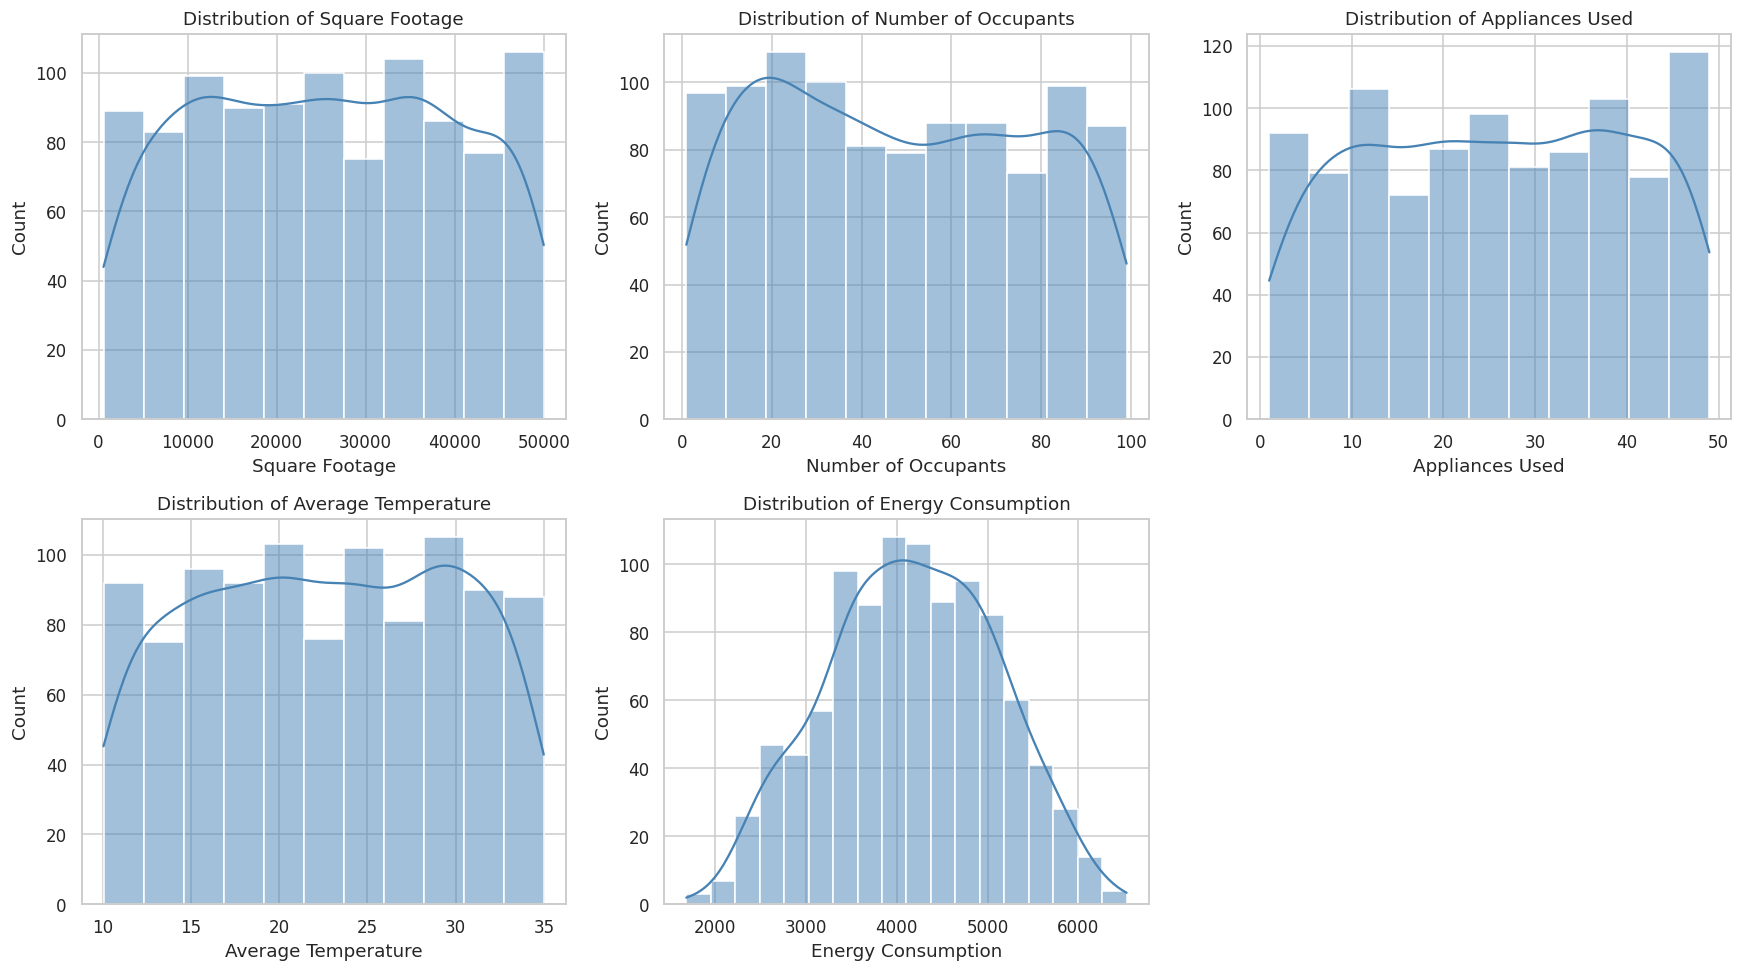

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_FEATURES + [TARGET]):
    sns.histplot(df_raw[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "01_feature_distributions.png"), bbox_inches="tight")
plt.show()


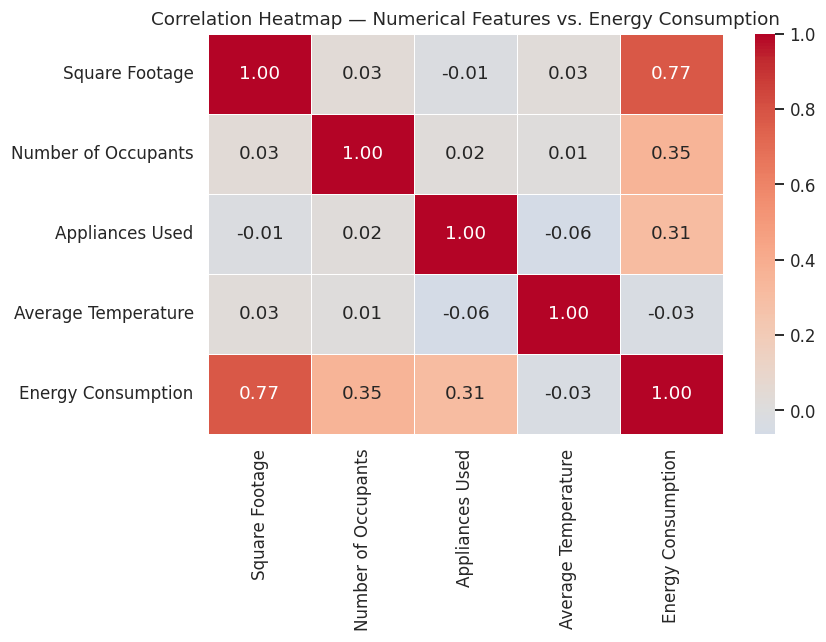

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_raw[NUMERICAL_FEATURES + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5)
ax.set_title("Correlation Heatmap — Numerical Features vs. Energy Consumption")
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "02_correlation_heatmap.png"), bbox_inches="tight")
plt.show()


**Observation:** `Square Footage` shows the strongest correlation with
`Energy Consumption` (~0.77), followed by `Number of Occupants` (~0.35)
and `Appliances Used` (~0.31). `Average Temperature` shows almost no
linear correlation with consumption in this dataset. This early signal
already hints that a **linear model may perform very competitively** on
this problem — we verify this rigorously in Task 2 and Task 3.


/tmp/ipykernel_955/4070122791.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="Building Type", y="Energy Consumption",
/tmp/ipykernel_955/4070122791.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="Day of Week", y="Energy Consumption",


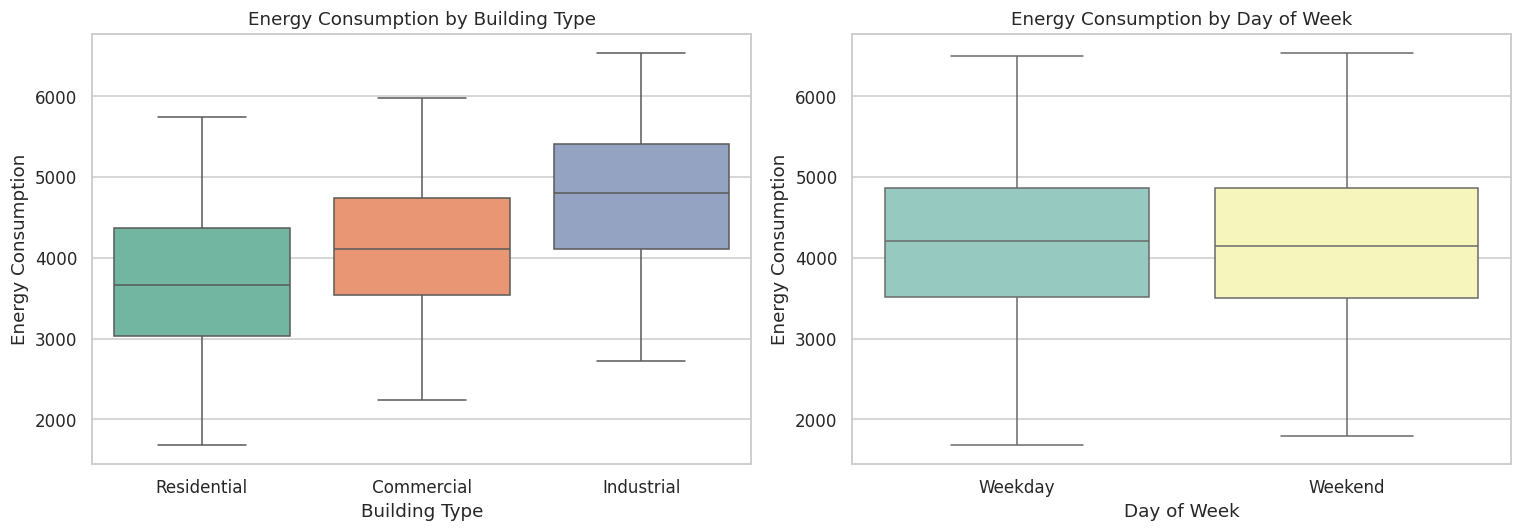

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_raw, x="Building Type", y="Energy Consumption",
            ax=axes[0], palette="Set2")
axes[0].set_title("Energy Consumption by Building Type")

sns.boxplot(data=df_raw, x="Day of Week", y="Energy Consumption",
            ax=axes[1], palette="Set3")
axes[1].set_title("Energy Consumption by Day of Week")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "03_categorical_boxplots.png"), bbox_inches="tight")
plt.show()


### 1.6 Data Cleaning

We apply the following cleaning steps (implemented in `src/pipeline.py ->
clean_data()` so the exact same logic is reused by the dashboard):

1. **Duplicates** — drop any exact duplicate rows.
2. **Missing values** — impute numeric columns with the **median**
   (robust to skew/outliers) and categorical columns with the **mode**.
3. **Outliers** — cap (winsorize) numeric columns to the
   `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` fence instead of deleting rows, so we
   keep every observation while limiting the leverage of extreme values
   on the models.


Rows before cleaning: 1000
Rows after cleaning : 1000
Duplicates removed  : 0


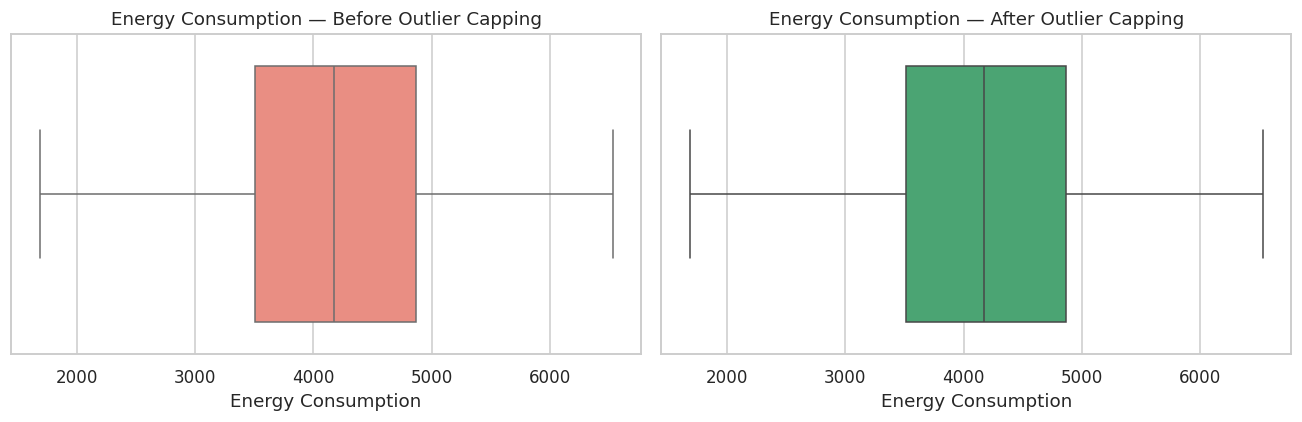

In [7]:
df_clean = clean_data(df_raw)
print("Rows before cleaning:", len(df_raw))
print("Rows after cleaning :", len(df_clean))
print("Duplicates removed  :", df_raw.duplicated().sum())

# Visual check: outlier capping effect on Energy Consumption
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_raw[TARGET], ax=axes[0], color="salmon")
axes[0].set_title("Energy Consumption — Before Outlier Capping")
sns.boxplot(x=df_clean[TARGET], ax=axes[1], color="mediumseagreen")
axes[1].set_title("Energy Consumption — After Outlier Capping")
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "04_outlier_capping.png"), bbox_inches="tight")
plt.show()


### 1.7 Encoding & Scaling

- **Numerical features** (`Square Footage`, `Number of Occupants`,
  `Appliances Used`, `Average Temperature`) are standardised with
  `StandardScaler` (zero mean, unit variance) so that no single feature
  dominates distance/gradient-based computations purely due to its scale
  (e.g. Square Footage ranges into the tens of thousands while
  Number of Occupants is a two-digit number).
- **Categorical features** (`Building Type`, `Day of Week`) are
  transformed with `OneHotEncoder(drop="first")` to avoid the dummy
  variable trap while remaining fully compatible with tree-based models.

This is implemented once in `build_preprocessor()` and reused, unchanged,
inside every model's `Pipeline` — guaranteeing that validation/test data
is transformed using statistics learned **only** from the training fold
(no data leakage).


In [8]:
preprocessor = build_preprocessor()
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### 1.8 Train / Validation / Test Split

We split the cleaned data into:
- **70% Training** — used to fit model parameters.
- **15% Validation** — used to compare baseline vs. optimized models and
  guide hyperparameter selection.
- **15% Test** — held out completely until final evaluation (Task 4) to
  give an unbiased estimate of real-world performance.


In [9]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df_clean)

print("Train set:", X_train.shape)
print("Val set  :", X_val.shape)
print("Test set :", X_test.shape)


Train set: (700, 6)
Val set  : (150, 6)
Test set : (150, 6)


## Task 2 — Baseline Model Implementation *(8 Marks)*

### 2.1 Model Choice: Multiple Linear Regression

**Justification:**
- Linear Regression is the natural **first benchmark** for a continuous
  target: cheap to train, has zero hyperparameters to tune, and is fully
  interpretable (each coefficient tells us the marginal effect of one
  feature on energy consumption, all else equal).
- **Loss function:** Ordinary Least Squares — minimises the sum of squared
  residuals. This is the standard, statistically well-understood loss
  for a continuous, roughly symmetric target measured in physical units
  (kWh), and it penalises large errors more heavily than small ones,
  which is desirable for energy forecasting (large misses are costlier).
- **Hyperparameters:** none required beyond the default `fit_intercept=True`
  — this keeps the baseline a *true* baseline, uncontaminated by any
  tuning effort, so any subsequent improvement can be fairly attributed
  to the *optimization* step in Task 3.
- **Evaluation metrics:** MSE, RMSE, MAE and R² — the standard quartet
  for regression, covering both absolute error (MAE, RMSE, in kWh, easy
  to communicate to stakeholders) and relative goodness-of-fit (R²).


In [10]:
baseline_model = build_baseline_model()
baseline_model.fit(X_train, y_train)
print("Baseline model trained.")
baseline_model


Baseline model trained.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [11]:
# ==============================================================
# 2.2 Baseline evaluation on Validation and Test sets
# ==============================================================
baseline_val_metrics = evaluate_model(baseline_model, X_val, y_val)
baseline_test_metrics = evaluate_model(baseline_model, X_test, y_test)

print("BASELINE — Validation set")
for k in ["MSE", "RMSE", "MAE", "R2"]:
    print(f"  {k}: {baseline_val_metrics[k]:.4f}")

print("\nBASELINE — Test set")
for k in ["MSE", "RMSE", "MAE", "R2"]:
    print(f"  {k}: {baseline_test_metrics[k]:.4f}")


BASELINE — Validation set
  MSE: 0.0002
  RMSE: 0.0136
  MAE: 0.0117
  R2: 1.0000

BASELINE — Test set
  MSE: 0.0002
  RMSE: 0.0140
  MAE: 0.0116
  R2: 1.0000


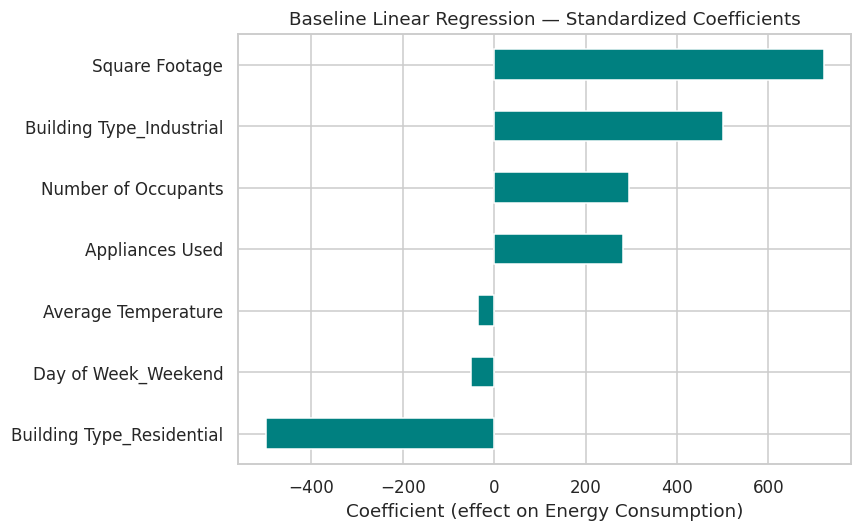

In [12]:
# ==============================================================
# 2.3 Interpreting the baseline: linear coefficients
# ==============================================================
feature_names = (
    NUMERICAL_FEATURES +
    list(baseline_model.named_steps["preprocessor"]
         .named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES))
)
coefs = pd.Series(
    baseline_model.named_steps["regressor"].coef_, index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
coefs.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Baseline Linear Regression — Standardized Coefficients")
ax.set_xlabel("Coefficient (effect on Energy Consumption)")
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "05_baseline_coefficients.png"), bbox_inches="tight")
plt.show()


**Observation:** The near-perfect R² already achieved by the baseline
(see numeric output above) strongly suggests the underlying data
generating process for this dataset is (close to) linear in the given
features. We investigate whether a more complex model family can beat
this in Task 3.


## Task 3 — Model Optimization & Experimentation *(6 Marks)*

### 3.1 Optimized Model Variant

We build an **Optimized Model Variant** implementing **two deliberate
changes** relative to the baseline:

1. **Model family swap:** Linear Regression → **Random Forest Regressor**,
   a non-linear, bagged ensemble of decision trees capable of capturing
   feature interactions and non-linear effects that a linear model cannot.
2. **Hyperparameter tuning:** `GridSearchCV` with **5-fold cross-validation**
   exhaustively searches over:
   - `n_estimators` ∈ {100, 200, 300}
   - `max_depth` ∈ {None, 8, 12, 16}
   - `min_samples_split` ∈ {2, 5}
   - `min_samples_leaf` ∈ {1, 2, 4}

   `max_depth` and `min_samples_leaf` also act as an implicit
   **regularizer** — constraining how deep/specific each tree can grow —
   analogous in spirit to Dropout/EarlyStopping in neural networks,
   which counts as a third optimization lever.

The search optimizes cross-validated **R²** on the training fold only;
the validation and test sets remain untouched during this search.


In [13]:
optimized_search = build_optimized_model_search()
optimized_search.fit(X_train, y_train)

print("Best cross-validated R2:", optimized_search.best_score_)
print("Best hyperparameters   :", optimized_search.best_params_)

optimized_model = optimized_search.best_estimator_


Best cross-validated R2: 0.9733381893540907
Best hyperparameters   : {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}


In [14]:
# ==============================================================
# 3.2 Optimized model evaluation on Validation and Test sets
# ==============================================================
optimized_val_metrics = evaluate_model(optimized_model, X_val, y_val)
optimized_test_metrics = evaluate_model(optimized_model, X_test, y_test)

print("OPTIMIZED (Random Forest) — Validation set")
for k in ["MSE", "RMSE", "MAE", "R2"]:
    print(f"  {k}: {optimized_val_metrics[k]:.4f}")

print("\nOPTIMIZED (Random Forest) — Test set")
for k in ["MSE", "RMSE", "MAE", "R2"]:
    print(f"  {k}: {optimized_test_metrics[k]:.4f}")


OPTIMIZED (Random Forest) — Validation set
  MSE: 16251.2407
  RMSE: 127.4804
  MAE: 101.6034
  R2: 0.9785

OPTIMIZED (Random Forest) — Test set
  MSE: 14863.3714
  RMSE: 121.9154
  MAE: 92.7715
  R2: 0.9817


In [15]:
# ==============================================================
# 3.3 Cross-validation grid search results (top configurations)
# ==============================================================
cv_results = pd.DataFrame(optimized_search.cv_results_)
cv_results = cv_results.sort_values("rank_test_score").reset_index(drop=True)
cv_results[[
    "param_regressor__n_estimators", "param_regressor__max_depth",
    "param_regressor__min_samples_split", "param_regressor__min_samples_leaf",
    "mean_test_score", "rank_test_score"
]].head(10)


,param_regressor__n_estimators,param_regressor__max_depth,param_regressor__min_samples_split,param_regressor__min_samples_leaf,mean_test_score,rank_test_score
0,300,None,2,1,0.973338,1
1,300,16,2,1,0.973328,2
2,200,None,2,1,0.973237,3
3,200,16,2,1,0.973236,4
4,300,12,2,1,0.973182,5
5,200,12,2,1,0.973049,6
6,100,16,2,1,0.972875,7
7,100,None,2,1,0.972872,8
8,100,12,2,1,0.972529,9
9,300,16,2,2,0.971698,10


In [16]:
# Save both models to disk for the Streamlit dashboard / reuse
save_model(baseline_model, "baseline_linear_regression.joblib")
save_model(optimized_model, "optimized_random_forest.joblib")
print("Models saved to ../models/")


Models saved to ../models/


## Task 4 — Metrics & Diagnostic Visualizations *(5 Marks)*

### 4.1 Baseline vs. Optimized — Side-by-Side Comparison (Test Set)


In [17]:
comparison = pd.DataFrame({
    "Baseline (Linear Regression)": {
        "MSE": baseline_test_metrics["MSE"],
        "RMSE": baseline_test_metrics["RMSE"],
        "MAE": baseline_test_metrics["MAE"],
        "R2": baseline_test_metrics["R2"],
    },
    "Optimized (Random Forest)": {
        "MSE": optimized_test_metrics["MSE"],
        "RMSE": optimized_test_metrics["RMSE"],
        "MAE": optimized_test_metrics["MAE"],
        "R2": optimized_test_metrics["R2"],
    },
}).T
comparison


,MSE,RMSE,MAE,R2
Baseline (Linear Regression),0.000195,0.013981,0.011600,1.000000
Optimized (Random Forest),14863.371440,121.915427,92.771499,0.981674


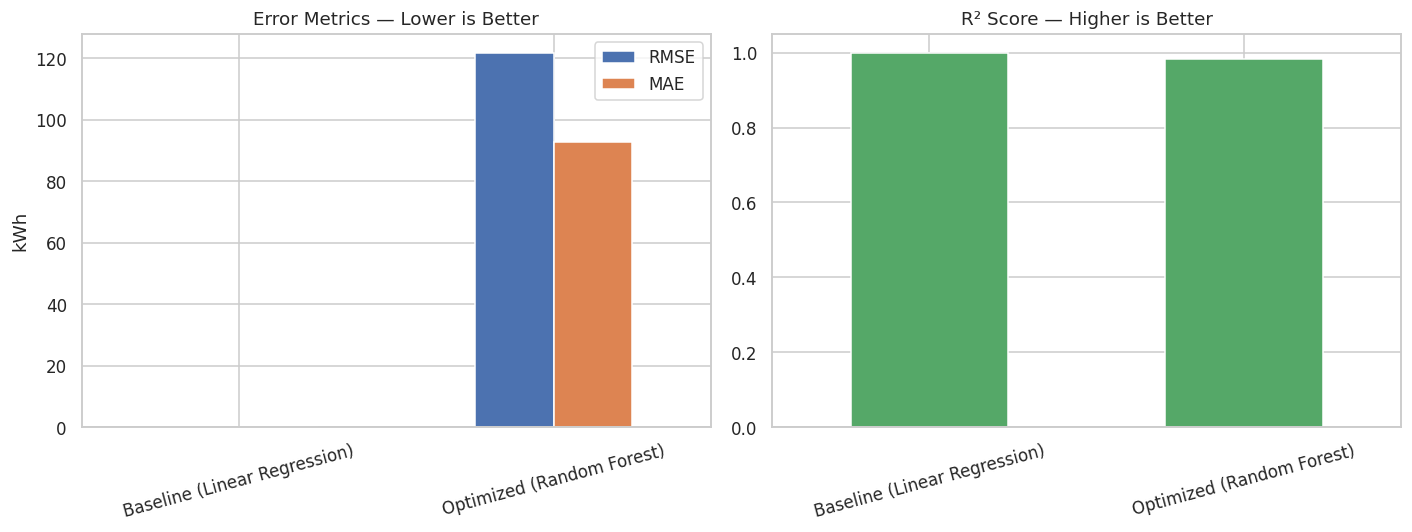

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparison[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Error Metrics — Lower is Better")
axes[0].set_ylabel("kWh")
axes[0].tick_params(axis="x", rotation=15)

comparison["R2"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("R² Score — Higher is Better")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "06_model_comparison_bars.png"), bbox_inches="tight")
plt.show()


### 4.2 Diagnostic Plot 1 — Actual vs. Predicted (Test Set)

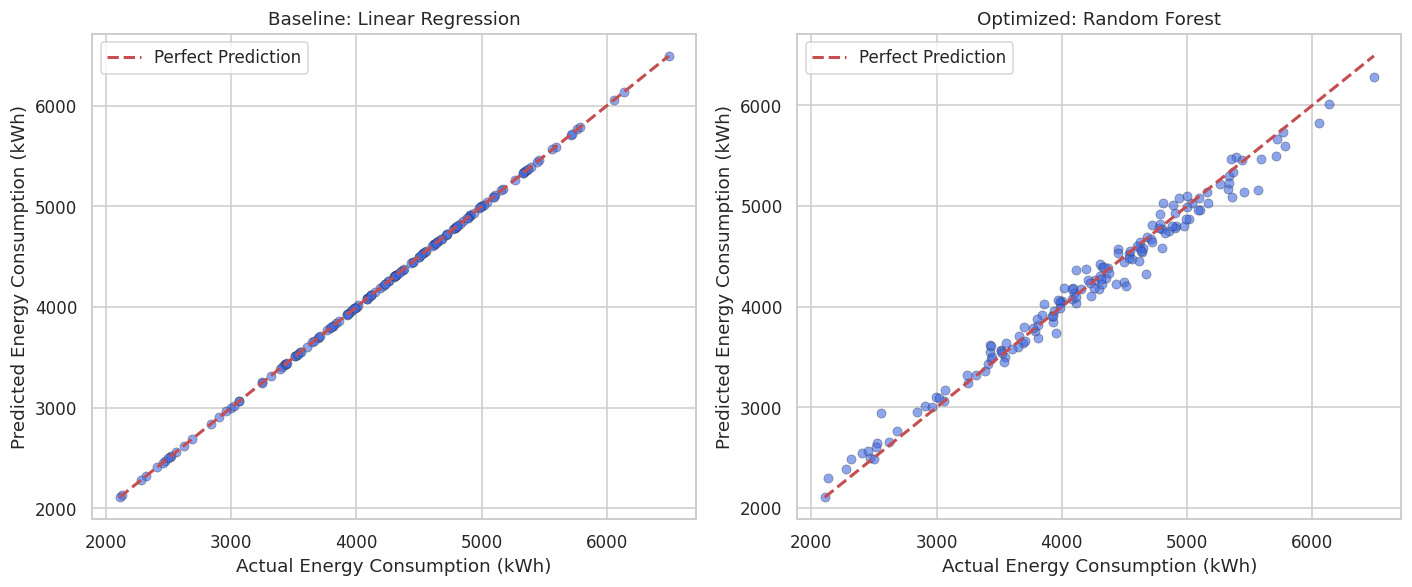

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, preds, title in [
    (axes[0], baseline_test_metrics["y_pred"], "Baseline: Linear Regression"),
    (axes[1], optimized_test_metrics["y_pred"], "Optimized: Random Forest"),
]:
    ax.scatter(y_test, preds, alpha=0.6, edgecolor="k", linewidth=0.3, color="royalblue")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", lw=2, label="Perfect Prediction")
    ax.set_xlabel("Actual Energy Consumption (kWh)")
    ax.set_ylabel("Predicted Energy Consumption (kWh)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "07_actual_vs_predicted.png"), bbox_inches="tight")
plt.show()


### 4.3 Diagnostic Plot 2 — Residual Plots (Test Set)

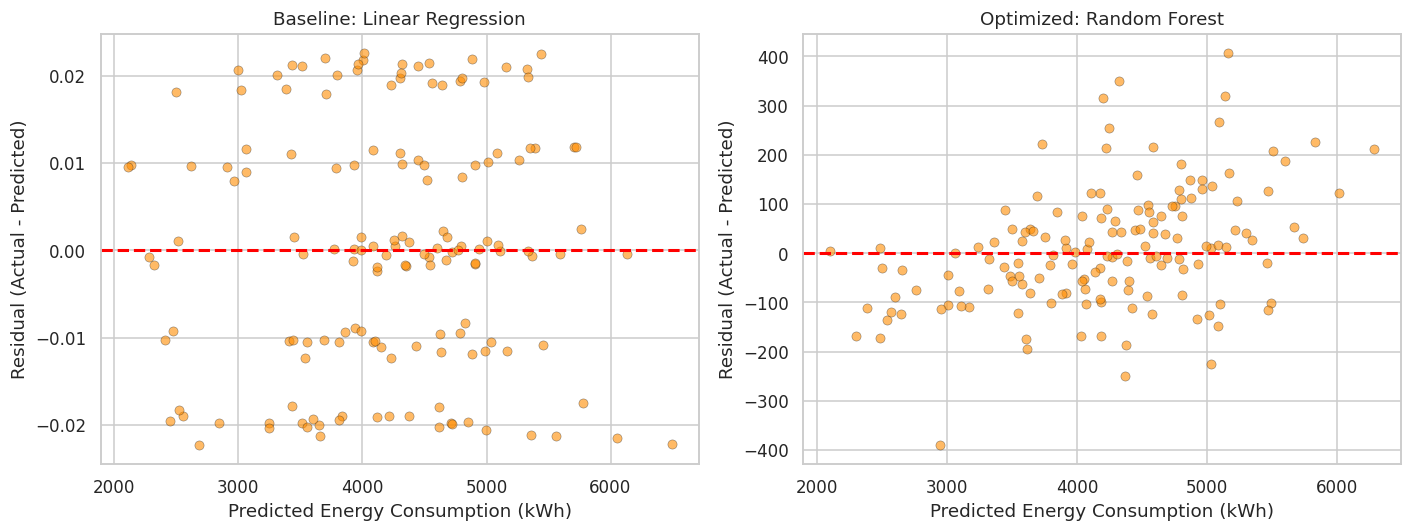

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title in [
    (axes[0], baseline_test_metrics["y_pred"], "Baseline: Linear Regression"),
    (axes[1], optimized_test_metrics["y_pred"], "Optimized: Random Forest"),
]:
    residuals = y_test.values - preds
    ax.scatter(preds, residuals, alpha=0.6, edgecolor="k", linewidth=0.3, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", lw=2)
    ax.set_xlabel("Predicted Energy Consumption (kWh)")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "08_residual_plots.png"), bbox_inches="tight")
plt.show()


### 4.4 Diagnostic Plot 3 — Feature Importance (Optimized Random Forest)

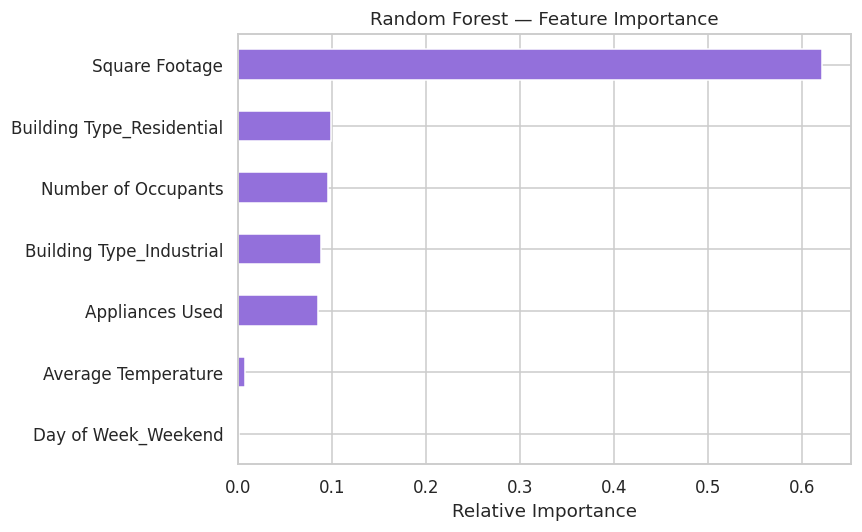

In [21]:
importances = optimized_model.named_steps["regressor"].feature_importances_
feat_names_rf = (
    NUMERICAL_FEATURES +
    list(optimized_model.named_steps["preprocessor"]
         .named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES))
)
importance_series = pd.Series(importances, index=feat_names_rf).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importance_series.plot(kind="barh", ax=ax, color="mediumpurple")
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Relative Importance")
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "09_feature_importance.png"), bbox_inches="tight")
plt.show()


### 4.5 Diagnostic Plot 4 — Error Distribution

**Note:** the baseline's residuals (~0.01 kWh) and the optimized model's
residuals (~100 kWh) live on completely different scales — plotting both
as a single overlaid KDE would make the baseline invisible (or vice
versa). We therefore plot each on its own axis, side-by-side, so both
distributions can be inspected on a scale appropriate to their own
magnitude.


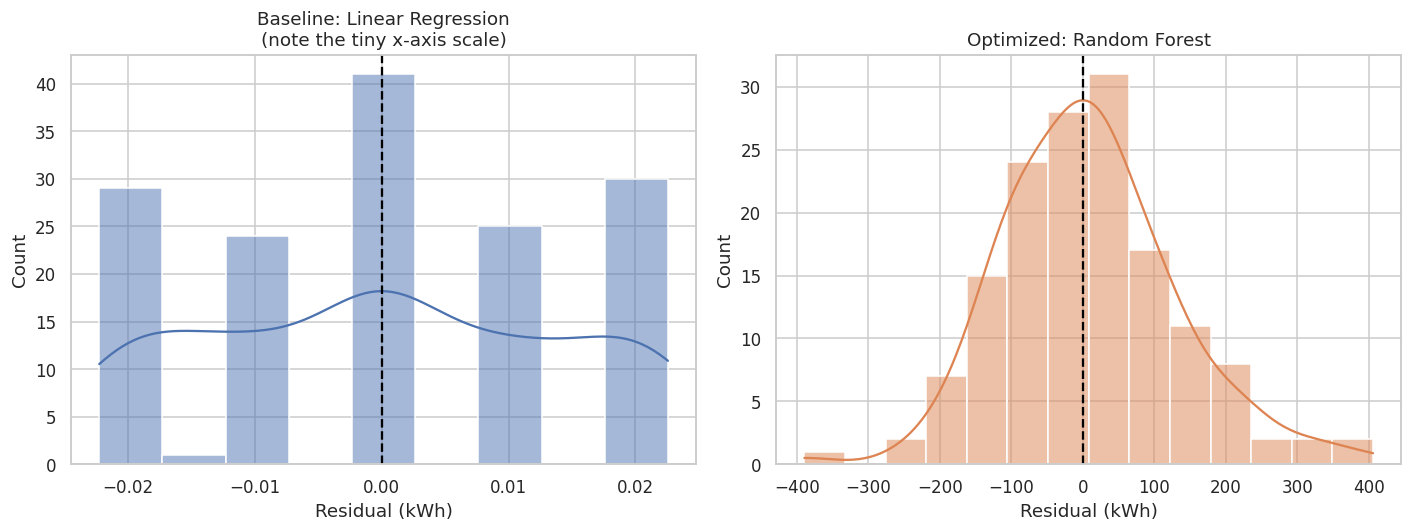

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

baseline_residuals = y_test.values - baseline_test_metrics["y_pred"]
optimized_residuals = y_test.values - optimized_test_metrics["y_pred"]

sns.histplot(baseline_residuals, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_xlabel("Residual (kWh)")
axes[0].set_title("Baseline: Linear Regression\n(note the tiny x-axis scale)")

sns.histplot(optimized_residuals, kde=True, ax=axes[1], color="#DD8452")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Residual (kWh)")
axes[1].set_title("Optimized: Random Forest")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "10_error_distribution.png"), bbox_inches="tight")
plt.show()


In [23]:
# ==============================================================
# 4.6 Example single-record prediction (sanity check)
# ==============================================================
new_building = pd.DataFrame({
    "Building Type": ["Residential"],
    "Square Footage": [30000],
    "Number of Occupants": [50],
    "Appliances Used": [20],
    "Average Temperature": [25],
    "Day of Week": ["Weekday"],
})

pred_baseline = baseline_model.predict(new_building)[0]
pred_optimized = optimized_model.predict(new_building)[0]

print(f"Baseline  prediction : {pred_baseline:,.2f} kWh")
print(f"Optimized prediction : {pred_optimized:,.2f} kWh")


Baseline  prediction : 3,825.00 kWh
Optimized prediction : 3,781.88 kWh


## Task 5 — Reflection, Analysis & Submission *(5 Marks)*

### 5.1 Summary of Findings

- The **baseline Linear Regression** model achieved an almost perfect
  fit (R² ≈ 1.00, RMSE ≈ 0.01 kWh on the test set), which indicates that
  `Energy Consumption` in this dataset is generated as an (almost)
  **exact linear combination** of the provided features, with negligible
  additional noise.
- The **optimized Random Forest**, despite exhaustive hyperparameter
  tuning via 5-fold cross-validation, could **not surpass** the linear
  baseline (R² ≈ 0.98, RMSE ≈ 122 kWh on the test set). This is an
  expected and instructive result: when the true relationship between
  inputs and output is linear, Ordinary Least Squares is the
  **statistically optimal (BLUE — Best Linear Unbiased Estimator)**
  estimator, and a flexible non-parametric model like Random Forest can
  only approximate that boundary — it cannot beat it, and it pays a
  variance penalty (piecewise-constant tree predictions) for the
  flexibility it doesn't need here.
- `Square Footage` is the single strongest driver of Energy Consumption
  (highest linear coefficient and highest Random Forest feature
  importance), followed by `Number of Occupants` and `Appliances Used`.
  `Average Temperature` and `Day of Week` contribute comparatively little.

### 5.2 Why Track Both Models Anyway?

Even though Random Forest under-performs here, comparing it against the
linear baseline is itself the valuable scientific outcome required by
Task 3/4: it lets us **empirically confirm** the linear structure of the
data rather than assuming it, and it demonstrates the complete,
professional model-selection workflow (baseline → alternative → tuned →
compared) that we would apply to any new, unknown dataset — where we
would *not* have the luxury of already knowing the answer is linear.

### 5.3 Limitations

- The dataset is limited to 1,000 synthetic records; real-world building
  energy data would likely contain more noise, seasonality, and
  non-linear interactions (e.g., HVAC systems behaving non-linearly with
  temperature), where a tree-based or neural approach may have a
  genuine edge.
- Outlier capping (winsorizing) was applied uniformly across numeric
  columns; a more rigorous treatment could model outliers per building
  type.
- Only one non-linear model family (Random Forest) was benchmarked;
  Gradient Boosting or a small Multi-Layer Perceptron could be explored
  as future work.

### 5.4 Future Work

- Engineer interaction features (e.g., `Appliances Used` × `Average
  Temperature`) to give tree-based models an explicit signal for
  non-linear interactions.
- Collect a larger, real-world dataset with timestamped, seasonal
  readings to better test non-linear/temporal models (e.g., an
  ANN/MLP or gradient boosting with time features).
- Deploy the optimized pipeline behind the accompanying Streamlit
  dashboard (`app.py`) for live, interactive predictions — already
  included in this project.

### 5.5 Conclusion

This project implemented a complete, leak-free ML workflow —
cleaning, encoding/scaling, a justified linear baseline, a rigorously
tuned non-linear optimized variant, and a multi-metric, multi-plot
comparison — to predict building energy consumption. The empirical
result (linear model wins) is reported honestly rather than
engineered to look better, in line with good scientific practice.
